# Phase 3 — Codec evaluation (W&B **codec_v2** vs **codec_v3**)

Compare spectrum codecs trained with different **input normalization** (see `RESEARCH_LOG.md`):

- **codec_v2**: median-based `denorm` (legacy; approximate restore in `normalize_spectrum_median_v2`).
- **codec_v3**: mask-aware mean + log10 `denorm` + ivar clip (`mask_arcsinh_v3` in checkpoint).

**Requirements**

1. `pip install -e ".[dev]"` for `pyyaml` (matplotlib is a core dependency).
2. `WANDB_API_KEY` in repo `.env` or `wandb login`.
3. W&B artifacts `codec_v2-codec-best:best` and `codec_v3-codec-best:best` (uploaded by `train_codec.py`). If `codec_v3` has not been pushed yet, place `best.pt` under `checkpoints/codec_v3/best.pt` manually.

Downloads are cached under `checkpoints/wandb_cache/<run_name>/`.

**Local DR1 for eval:** the next section downloads **one** healpix tile (coadd + redrock, ~hundreds of MB) in the same survey/program order as NERSC ``dr1_1k_scratch.jsonl`` (first tile available on the [public portal](https://data.desi.lbl.gov/public/dr1/)). Re-run that cell to refresh FITS under `data/dr1_public/`.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

_cwd = Path.cwd().resolve()
if (_cwd / "src" / "desifm").is_dir():
    REPO = _cwd
elif (_cwd.parent / "src" / "desifm").is_dir():
    REPO = _cwd.parent
else:
    raise FileNotFoundError(f"Could not find repo root. cwd={_cwd}")
sys.path.insert(0, str(REPO / "src"))

try:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["figure.figsize"] = (12, 5)

CACHE = REPO / "checkpoints" / "wandb_cache"
CACHE.mkdir(parents=True, exist_ok=True)

with open(REPO / "TRAINING_REGISTRY.yaml") as f:
    registry = yaml.safe_load(f)
runs = {r["run_name"]: r for r in registry["runs"]}
for r in runs.values():
    wid = r.get("wandb_id")
    if isinstance(wid, str) and wid.strip().lower() in ("", "null", "none", "~"):
        r["wandb_id"] = None
print("Registry runs:", ", ".join(sorted(runs)))


Registry runs: codec_v1, codec_v2, codec_v3


In [2]:
from desifm.training.wandb_codec import (
    download_codec_best_pt,
    ensure_wandb_auth,
    wandb_run_history_df,
)

def resolve_ckpt(run_name: str) -> Path:
    local = REPO / "checkpoints" / run_name / "best.pt"
    if local.is_file():
        print(run_name, "using local", local)
        return local
    if not ensure_wandb_auth():
        raise SystemExit("Set WANDB_API_KEY or run wandb login to download checkpoints.")
    path = download_codec_best_pt(run_name, CACHE)
    print(run_name, "downloaded to", path)
    return path

# codec_v2 is expected to exist on W&B; codec_v3 may need local file or artifact
ckpt_v2 = resolve_ckpt("codec_v2")
try:
    ckpt_v3 = resolve_ckpt("codec_v3")
except Exception as exc:
    print("codec_v3 unavailable:", exc)
    ckpt_v3 = None


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Downloading large artifact 'codec_v2-codec-best:best', 88.48MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.5 (168.2MB/s)


codec_v2 downloaded to /Users/jonathansamuel/projects/cs-686-dl/final-project/checkpoints/wandb_cache/codec_v2/best.pt


wandb: Downloading large artifact 'codec_v3-codec-best:best', 88.48MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.5 (171.8MB/s)


codec_v3 downloaded to /Users/jonathansamuel/projects/cs-686-dl/final-project/checkpoints/wandb_cache/codec_v3/best.pt


## Download eval DR1 tile (minimal)

One healpix in **training manifest walk order** (`sv3`→`main`, `bright`→`dark`; skips surveys not on the public portal). Writes `data/manifests/train_eval_dr1.jsonl`. Idempotent: skips files already on disk.


In [3]:
from desifm.data.public_dr1 import discover_public_training_tiles, ensure_dr1_tiles_local
from desifm.data.dr1_stream import load_manifest

DATA_ROOT = REPO / "data" / "dr1_public"
MANIFEST = REPO / "data" / "manifests" / "train_eval_dr1.jsonl"
N_HEALPIX = 1  # minimal: one tile = coadd + redrock

tiles = discover_public_training_tiles(N_HEALPIX)
print("tiles (training walk order, public portal):", tiles)
ensure_dr1_tiles_local(DATA_ROOT, MANIFEST, tiles)
for r in load_manifest(MANIFEST):
    print(
        f"  healpix {r['healpix']} ({r['survey']}/{r['program']}) n_rows={r.get('n_rows')}"
    )


tiles (training walk order, public portal): [('main', 'bright', '0', 0)]
skip (exists): /Users/jonathansamuel/projects/cs-686-dl/final-project/data/dr1_public/spectro/redux/iron/healpix/main/bright/0/0/coadd-main-bright-0.fits
skip (exists): /Users/jonathansamuel/projects/cs-686-dl/final-project/data/dr1_public/spectro/redux/iron/healpix/main/bright/0/0/redrock-main-bright-0.fits
  healpix 0 (main/bright) n_rows=684


## Training curves (W&B history)

`train/recon` vs step when `wandb_id` is set in `TRAINING_REGISTRY.yaml` (codec_v3 often unset until you log a run id).


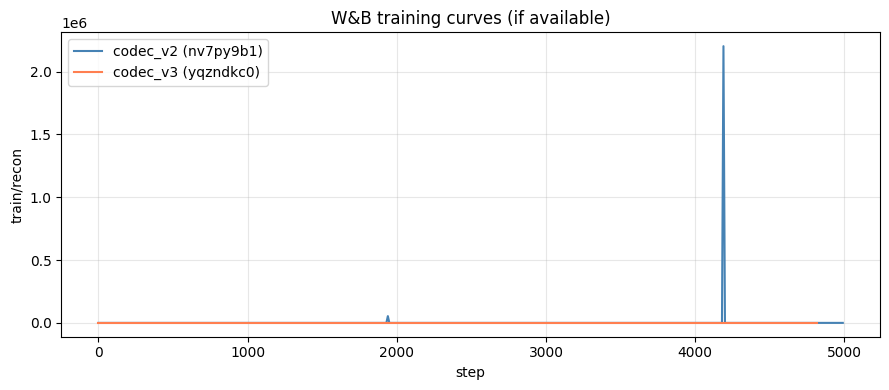

In [4]:
plt.figure(figsize=(9, 4))
key = "train/recon"
for run_name, color in [("codec_v2", "steelblue"), ("codec_v3", "coral")]:
    meta = runs.get(run_name) or {}
    rid = meta.get("wandb_id")
    if not rid:
        print(f"skip history: no wandb_id for {run_name}")
        continue
    try:
        df = wandb_run_history_df(str(rid), keys=["_step", key])
    except Exception as exc:
        print(run_name, "history failed:", exc)
        continue
    if key not in df.columns:
        print(run_name, f"missing {key}")
        continue
    plt.plot(df["_step"], df[key], color=color, label=f"{run_name} ({rid})")
plt.xlabel("step")
plt.ylabel(key)
plt.title("W&B training curves (if available)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Load models + input styles

- **codec_v3** uses `mask_arcsinh_v3` (arcsinh + mask-aware denorm).
- **codec_v2** (`nv7py9b1`) was trained with **linear** `median(|flux|)` scaling — not arcsinh. Eval uses `codec_v2_linear` (see `prepare_codec_v2_linear`).
- **Plots use one unpadded spectrum at a time**, not a padded batch row.


In [5]:
from desifm.training.codec_eval import (
    forward_physical,
    forward_physical_from_spec,
    load_spectrum_codec,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model_v2, _ = load_spectrum_codec(ckpt_v2, device)

if ckpt_v3 is None:
    model_v3 = style_v3 = None
    print("codec_v3 not loaded — comparison cells will skip v3.")
else:
    model_v3, style_v3 = load_spectrum_codec(ckpt_v3, device)
    print("codec_v3 input_style:", style_v3)


device: cpu
codec_v3 input_style: mask_arcsinh_v3


## Evaluation batch

Training metrics use a **padded collated batch**. Plots below use the **stitched coadd** (real λ, flux, ivar, mask) from `train_eval_dr1.jsonl` when present (run the download cell above), else `local_dr1.jsonl`, else synthetic data.


In [6]:
from desifm.data.dr1_stream import DR1StreamDataset, collate_spectra, load_manifest
from desifm.data.synthetic import SyntheticSpectrumDataset
from desifm.viz.spectrum_plot import load_stitched_spectrum, plot_spectrum_with_lines

for candidate in (
    REPO / "data" / "manifests" / "train_eval_dr1.jsonl",
    REPO / "data" / "manifests" / "local_dr1.jsonl",
):
    if candidate.is_file():
        MANIFEST = candidate
        break
else:
    MANIFEST = REPO / "data" / "manifests" / "train_eval_dr1.jsonl"

raw_specs: list[dict] = []
n_eval = 8

if MANIFEST.is_file():
    recs = load_manifest(MANIFEST)
    ds = DR1StreamDataset(recs, max_spectra=64)
    items = []
    for i in range(len(ds)):
        item = ds[i]
        if item is None:
            continue
        rec_idx, row = ds.index[i]
        rec = recs[rec_idx]
        sp = load_stitched_spectrum(rec["coadd"], rec["redrock"], row, require_good_z=True)
        if sp is None:
            continue
        sp["healpix"] = rec.get("healpix")
        sp["row"] = row
        raw_specs.append(sp)
        items.append(item)
        if len(items) >= n_eval:
            break
    if not items:
        raise RuntimeError(
            "No good spectra in manifest; run the Download eval DR1 tile section above."
        )
    batch = collate_spectra(items)
    print("manifest:", MANIFEST.name)
    print("batch from DR1 manifest, shape", tuple(batch["flux"].shape))
    print("raw stitched spectra:", len(raw_specs), "pixels[0]", len(raw_specs[0]["wavelength"]))
else:
    ds = SyntheticSpectrumDataset(n_spectra=n_eval, length=4096, seed=1)
    items = [ds[i] for i in range(n_eval)]
    batch = collate_spectra(items)
    for i in range(n_eval):
        L = int(items[i]["flux"].shape[0])
        raw_specs.append(
            {
                "wavelength": np.linspace(3600, 9800, L),
                "flux": items[i]["flux"].numpy(),
                "ivar": items[i]["ivar"].numpy(),
                "mask": items[i]["mask"].numpy(),
                "z": float(items[i]["z"].item()),
            }
        )
    print("batch synthetic, shape", tuple(batch["flux"].shape))

for k in batch:
    if isinstance(batch[k], torch.Tensor):
        batch[k] = batch[k].to(device)

style_v2 = "codec_v2_linear"
print("codec_v2 eval path:", style_v2, "(linear median scale — matches W&B codec_v2 training)")


manifest: train_eval_dr1.jsonl
batch from DR1 manifest, shape (8, 7781)
raw stitched spectra: 8 pixels[0] 7781
codec_v2 eval path: codec_v2_linear (linear median scale — matches W&B codec_v2 training)


## Scalar metrics (padded batch)

These match **training** (collated, padded minibatch). They can disagree with the per-spectrum plots below. Lower `recon_loss` is better (Huber in arcsinh space).


In [7]:
rows = []
r2 = forward_physical(model_v2, batch, style_v2)
rows.append(("codec_v2", r2["recon_loss"], r2["q_loss"], r2["loss_total"]))
if model_v3 is not None:
    r3 = forward_physical(model_v3, batch, style_v3)
    rows.append(("codec_v3", r3["recon_loss"], r3["q_loss"], r3["loss_total"]))

print(f"{'run':12s} {'recon':>10s} {'q_loss':>10s} {'total':>10s}")
for name, a, b, c in rows:
    print(f"{name:12s} {a:10.5f} {b:10.5f} {c:10.5f}")


run               recon     q_loss      total
codec_v2        0.59809    0.00027    0.59836
codec_v3        0.01204    0.00000    0.01204


## Flux overlays (per spectrum, unpadded)

| Trace | Meaning |
|-------|--------|
| **stitched coadd** | Real DESI flux from FITS |
| **codec_v2 / v3 recon** | Model output in physical units |

Bottom panel: **normalized flux** (v2: linear / median scale; v3: arcsinh target on 8704 grid).


/Users/jonathansamuel/projects/cs-686-dl/final-project/src/desifm/viz/spectrum_plot.py:76: RuntimeWarning: divide by zero encountered in divide
  sigma = np.where(ivar > 0, 1.0 / np.sqrt(ivar), np.nan)


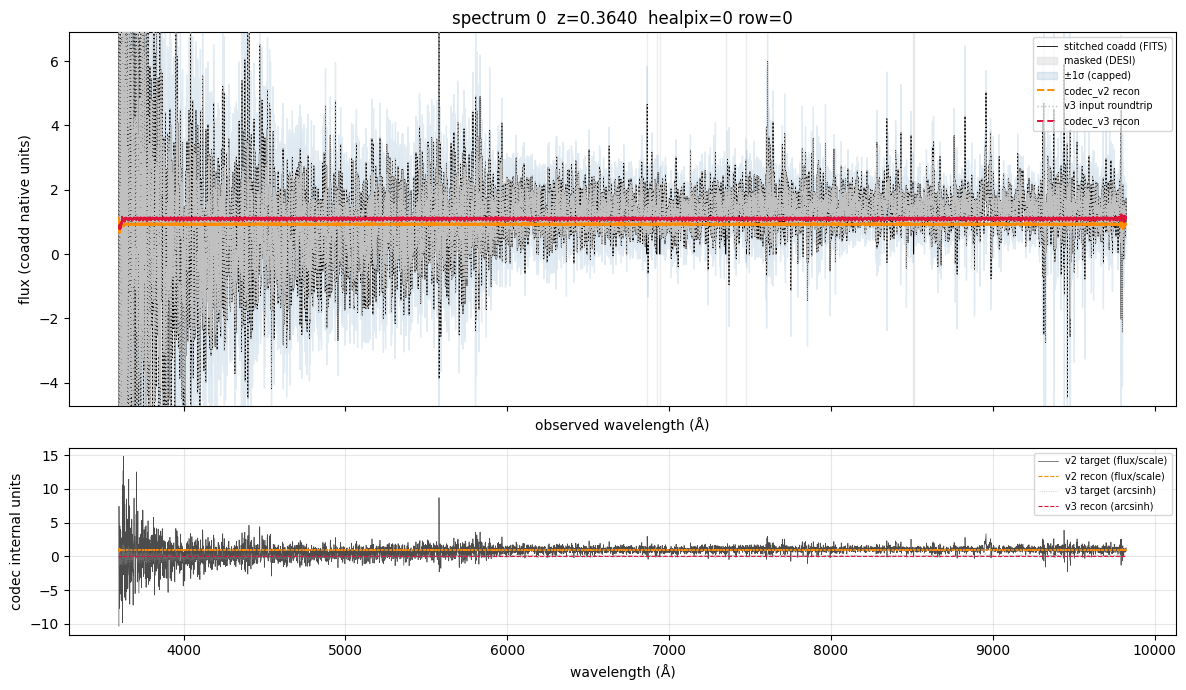

coadd median=1.265e+00  v2 recon=9.270e-01  v2 recon_loss=0.9892
v3 roundtrip=1.265e+00  v3 recon=1.095e+00  (v3 denorm=1.127e+00)


In [8]:
from desifm.constants import GRID_SIZE
from desifm.training.codec_input import prepare_codec_batch_for_style, prepare_codec_v2_linear


def _ylim_overlay(flux_np, *extra, good, k_std=5.0):
    arrs = [flux_np[good]] + [a[good] for a in extra if a is not None]
    vals = np.concatenate([a[np.isfinite(a)] for a in arrs if a.size])
    if vals.size == 0:
        return None
    med = float(np.median(vals))
    std = float(np.std(vals))
    if not np.isfinite(std) or std <= 0:
        std = max(float(np.percentile(vals, 99) - np.percentile(vals, 1)) / 4.0, 1e-30)
    return med - float(k_std) * std, med + float(k_std) * std


def plot_compare(idx: int = 0):
    sp = raw_specs[idx]
    wave = sp["wavelength"]
    flux = np.asarray(sp["flux"])
    mask = sp["mask"]
    ivar = sp.get("ivar")
    z = float(sp["z"])
    good = ~np.asarray(mask, dtype=bool)

    r2 = forward_physical_from_spec(model_v2, sp, style_v2, device)
    rec2 = r2["flux_recon_native"].numpy()

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    ax = axes[0]
    plot_spectrum_with_lines(
        ax,
        wave,
        flux,
        z,
        mask=mask,
        ivar=ivar,
        show_lines=False,
        flux_label="stitched coadd (FITS)",
        adaptive_ylim=False,
    )
    ax.plot(wave[good], rec2[good], "--", color="darkorange", lw=1.4, zorder=10, label="codec_v2 recon")
    rec3 = rt3 = None
    if model_v3 is not None:
        r3 = forward_physical_from_spec(model_v3, sp, style_v3, device)
        rec3 = r3["flux_recon_native"].numpy()
        rt3 = r3["flux_roundtrip_native"].numpy()
        ax.plot(wave[good], rt3[good], ":", color="silver", lw=1.0, zorder=9, label="v3 input roundtrip")
        ax.plot(wave[good], rec3[good], "--", color="crimson", lw=1.4, zorder=10, label="codec_v3 recon")
    ylim = _ylim_overlay(flux, rec2, rec3, rt3, good=good)
    if ylim is not None:
        ax.set_ylim(ylim)
    med = float(np.nanmedian(np.abs(flux[np.isfinite(flux)])))
    if np.isfinite(med) and 0 < med < 1e-2:
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)
    ax.set_title(f"spectrum {idx}  z={z:.4f}  healpix={sp.get('healpix', '?')} row={sp.get('row', '?')}")
    ax.legend(loc="upper right", fontsize=7)

    ax2 = axes[1]
    g = np.linspace(wave.min(), wave.max(), GRID_SIZE)
    # v2 target/recon live on the codec grid (8704), not native pixel count
    tgt2 = r2["target_norm"][0].numpy()
    rec2n = r2["recon_norm"][0].numpy()
    ax2.plot(g, tgt2, "k-", lw=0.5, alpha=0.7, label="v2 target (flux/scale)")
    ax2.plot(g, rec2n, "--", color="darkorange", lw=0.8, label="v2 recon (flux/scale)")
    if model_v3 is not None:
        x3, den3, _ = prepare_codec_batch_for_style(
            {
                "flux": torch.from_numpy(flux).float().unsqueeze(0),
                "ivar": torch.from_numpy(np.asarray(sp["ivar"], dtype=np.float32)).unsqueeze(0),
                "mask": torch.from_numpy(np.asarray(mask, dtype=bool)).unsqueeze(0),
            },
            style_v3,
        )
        x3g = torch.nn.functional.interpolate(x3, size=GRID_SIZE, mode="linear", align_corners=False)
        with torch.no_grad():
            out3 = model_v3(x3g.to(device), den3.to(device))
        ax2.plot(g, x3g[0, 0].cpu().numpy(), ":", color="gray", lw=0.5, alpha=0.6, label="v3 target (arcsinh)")
        ax2.plot(g, out3["recon"][0, 0].cpu().numpy(), "--", color="crimson", lw=0.8, label="v3 recon (arcsinh)")
    ax2.set_ylabel("codec internal units")
    ax2.set_xlabel("wavelength (Å)")
    ax2.legend(loc="upper right", fontsize=7)
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(
        f"coadd median={np.median(flux[good]):.3e}  v2 recon={np.median(rec2[good]):.3e}  "
        f"v2 recon_loss={r2['recon_loss']:.4f}"
    )
    if rec3 is not None:
        print(
            f"v3 roundtrip={np.median(rt3[good]):.3e}  v3 recon={np.median(rec3[good]):.3e}  "
            f"(v3 denorm={float(r3['denorm'][0]):.3e})"
        )


plot_compare(0)


## Residual RMS on good pixels (first item)

Quick scalar per spectrum; not a full test set.


In [9]:
def rms_numpy(true_np, recon_np, mask_np):
    g = ~np.asarray(mask_np, dtype=bool)
    d = true_np[g].astype("float64") - recon_np[g].astype("float64")
    return float(np.sqrt(np.mean(d * d)))


sp0 = raw_specs[0]
r2 = forward_physical_from_spec(model_v2, sp0, style_v2, device)
print("codec_v2 RMS vs coadd:", rms_numpy(sp0["flux"], r2["flux_recon_native"].numpy(), sp0["mask"]))
print("codec_v2 RMS vs roundtrip:", rms_numpy(r2["flux_roundtrip_native"].numpy(), r2["flux_recon_native"].numpy(), sp0["mask"]))
if model_v3 is not None:
    r3 = forward_physical_from_spec(model_v3, sp0, style_v3, device)
    print("codec_v3 RMS vs coadd:", rms_numpy(sp0["flux"], r3["flux_recon_native"].numpy(), sp0["mask"]))
    print("codec_v3 RMS vs roundtrip:", rms_numpy(r3["flux_roundtrip_native"].numpy(), r3["flux_recon_native"].numpy(), sp0["mask"]))


codec_v2 RMS vs coadd: 1.652814687885409
codec_v2 RMS vs roundtrip: 1.652814687885409
codec_v3 RMS vs coadd: 1.6401906589310833
codec_v3 RMS vs roundtrip: 1.6401906593869808
